In [1]:
"""
Aim: compare Fredrik's annotation of Acinar & Ductal subtypes with two published papers
Author: Yike Xie
Date: 27th-Mar-2025
"""

"\nAim: compare Fredrik's annotation of Acinar & Ductal subtypes with two published papers\nAuthor: Yike Xie\nDate: 27th-Mar-2025\n"

In [2]:
import utils

import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
# load data
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

In [4]:
# 1. normalize and log-transform
utils.normalizedata(adata, log1p=True)

AnnData object with n_obs × n_vars = 57935 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cell_subtype1', 'cell_subtype2'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [5]:
metadata = pd.read_csv('../tables/DESeq/pseudo_bulk_sum/metadata.tsv', sep='\t', index_col=0)
from matplotlib.patches import Patch

In [21]:
import gseapy as gp
from gseapy.plot import barplot
import os

def gsea_analysis(genes, path, fn, title):
    res = gp.enrichr(gene_list=genes,
                     gene_sets=['GO_Biological_Process_2023'],
                     organism='Human',
                     cutoff=0.05)
    res.res2d.to_csv(os.path.join(path, fn + '.tsv'), sep='\t')

    barplot(res.res2d, column='Adjusted P-value', Group='Gene_Set',
            size=10, top_term=10, 
            title=title, ofname=os.path.join(path, fn + '.png'),
            cutoff=1.0)
    return res

# Ductal cells

In [36]:
ductal_genes = [
    # expressed in all subtypes 
    'BICC1', 'ANXA4', 'GLIS3', 'SCTR',
    # MUC5B+ Ductal
    'MUC5B', 'TFF3', 
    # higher in ductal than in MUC5B+ Ductal
    'CFTR', 'SLC4A4',
                ]

In [37]:
adata_ductal = adata[adata.obs['cell_type'] == 'Ductal', ductal_genes].copy()
# scale on these genes
sc.pp.scale(adata_ductal, zero_center=True)

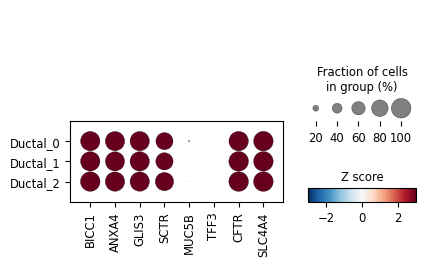

In [49]:
sc.pl.dotplot(adata_ductal, 
              var_names = ductal_genes, 
              groupby = 'cell_subtype',
              color_map='RdBu_r',  # Blue to red diverging
              colorbar_title = 'Z score',
              vcenter=0, vmin=-3, vmax=3
              )

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


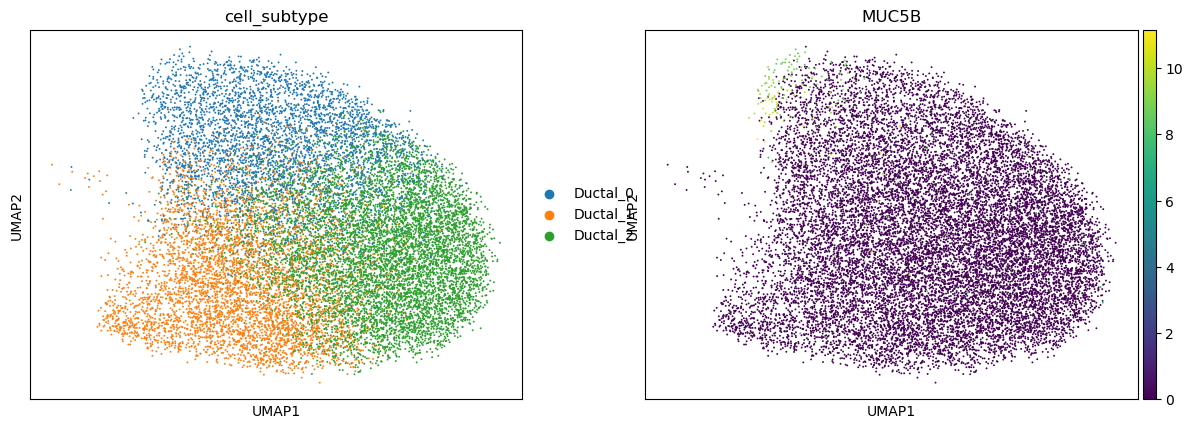

In [50]:
sc.pl.umap(adata[adata.obs['cell_type'] == 'Ductal'], color=['cell_subtype', 'MUC5B'])

In [51]:
from scipy.stats import ks_2samp

In [83]:
ks_res = ks_2samp(adata[adata.obs['cell_subtype'] == 'Ductal_0'].X.mean(axis=0), 
                  adata[adata.obs['cell_subtype'].isin(['Ductal_1', 'Ductal_2'])].X.mean(axis=0))
log2fc = np.log2(adata[adata.obs['cell_subtype'] == 'Ductal_0'].X.mean(axis=0) + 0.1) \
    - np.log2(adata[adata.obs['cell_subtype'].isin(['Ductal_1', 'Ductal_2'])].X.mean(axis=0) + 0.1)
ductal_DEG = pd.DataFrame(np.asarray(log2fc)[0], index=adata.var_names, columns=['log2fc'])
ductal_DEG['signed_statistic'] = ks_res.statistic * ks_res.statistic_sign
ductal_DEG['pvalue'] = ks_res.pvalue

In [84]:
ductal_DEG.sort_values('pvalue')[:50]

,log2fc,signed_statistic,pvalue
gene,,,
ENSG00000291299,-0.128193,1.0,1.0
PRSS30P-1,-0.130898,1.0,1.0
ENSG00000291301,0.023925,-1.0,1.0
POLGARF,0.067372,-1.0,1.0
LY6S,-0.020242,1.0,1.0
ENSG00000291313,0.004621,-1.0,1.0
ENSG00000291316,-0.047704,1.0,1.0
TMEM276,0.077450,-1.0,1.0
ENSG00000291286,-0.002598,1.0,1.0


/tmp/ipykernel_13627/4139305293.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_ductal.obs.groupby(['cell_subtype', 'sample',]).size().unstack().T


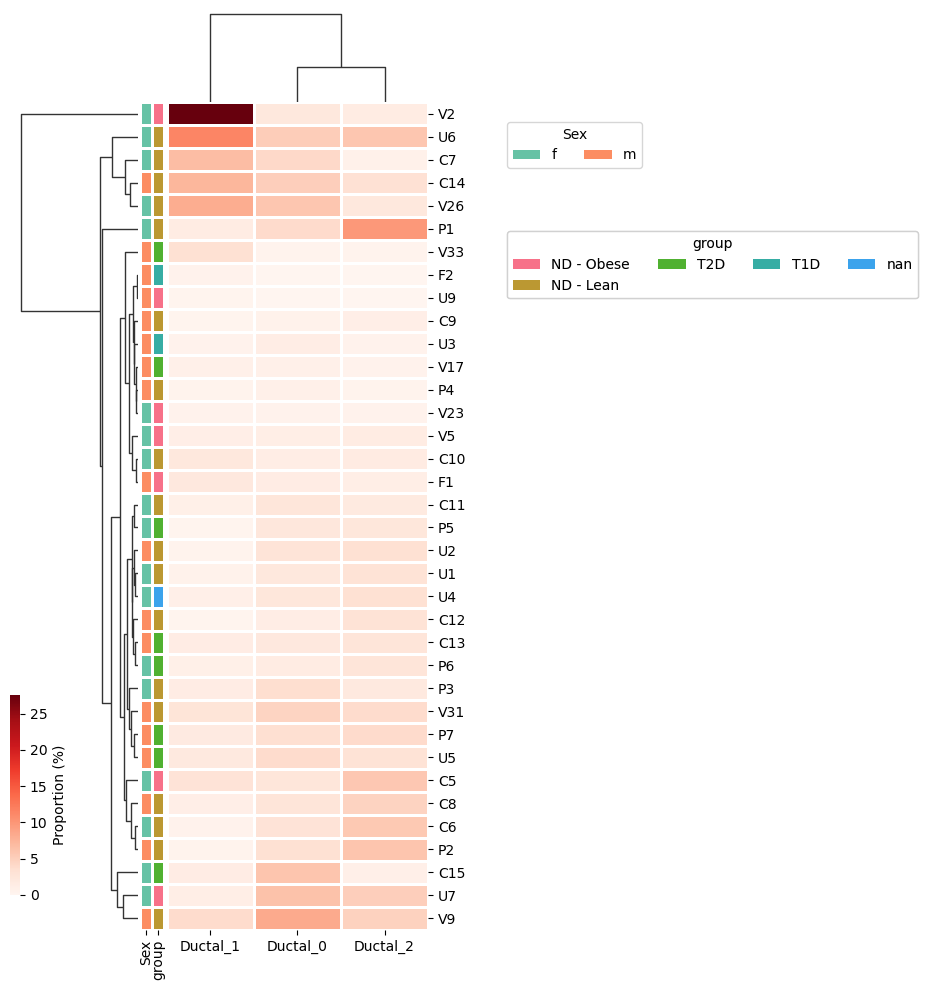

In [47]:
df = adata_ductal.obs.groupby(['cell_subtype', 'sample',]).size().unstack().T
df = (df / df.sum(axis=0) * 100)

color_elements1 = sns.color_palette('Set2')
color_elements2 = sns.color_palette('husl')

color_dict = {}
handles = {}
color_cols = {}

for col, color_elements in zip(['Sex','group'], [color_elements1, color_elements2]):
    color_col = dict(zip(metadata[col].unique(), color_elements[:len(metadata[col].unique())]))
    color_dict[col] = metadata[col].map(color_col)
    handles[col] = [Patch(facecolor=color, label=name) 
                    for name, color in color_col.items()]
    color_cols[col] = color_col

color_df = pd.DataFrame(color_dict, index=metadata.index)

g = sns.clustermap(
    df,
    cmap='Reds',
    row_colors=color_df,
    linewidths=0.9,
    cbar_pos=[0.02, 0.1, 0.02, 0.2],
    cbar_kws={'label':'Proportion (%)'},
    tree_kws={'linewidths': 1},
    dendrogram_ratio=(0.3, 0.1),
    figsize=[5, 10]
        )

g.ax_heatmap.set_xlabel(None)
g.ax_heatmap.set_ylabel(None)

fig = plt.gcf()

for i, col in enumerate(['Sex', 'group']):


    legend = plt.legend(handles[col], 
                        [patch.get_label() for patch in handles[col]],
                        title=col,
                        bbox_to_anchor=(1, 0.85- 0.12 * i), 
                        bbox_transform=plt.gcf().transFigure, 
                        loc='center left', ncols = min(4, len(handles[col])))
    fig.add_artist(legend)

In [48]:
adata_ductal.obs.groupby(['cell_subtype', 'sample',]).size().unstack().T

/tmp/ipykernel_13627/2880842277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_ductal.obs.groupby(['cell_subtype', 'sample',]).size().unstack().T


cell_subtype,Ductal_0,Ductal_1,Ductal_2
sample,,,
C5,95,140,431
C6,114,25,421
C7,157,319,52
C8,98,52,352
C9,24,11,88
C10,51,104,124
C11,96,45,143
C12,53,13,226
C13,78,67,198


# Recluster ductal cells

In [6]:
adata_ductal = adata[adata.obs['cell_type'] == 'Ductal'].copy()

In [7]:
batch_label = 'sample'
neighbors_within_batch = 3
resolution = 1.1

incompatible = utils.return_incompatible(adata_ductal, batch_label, neighbors_within_batch)
print(f'There is not enough cells within {incompatible}, continuing without these batches')
ductal = adata_ductal[~ adata_ductal.obs[batch_label].isin(incompatible)]

sc.pp.highly_variable_genes(ductal, n_top_genes=2000) 
print('PCA')
sc.tl.pca(ductal)
print('Infer neighbors')
sc.pp.neighbors(ductal)
print('# Run BBKNN to correct batch effects by aligning neighbors across batches')
sc.external.pp.bbknn(ductal, batch_key=batch_label, neighbors_within_batch=neighbors_within_batch)  
print('Run UMAP')
sc.tl.umap(ductal)
print('Find communities')
sc.tl.leiden(ductal, flavor="igraph", n_iterations=2, 
             resolution=resolution, key_added=f"leiden_r{resolution}")
print('finished')

There is not enough cells within [], continuing without these batches


/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:696: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


PCA
Infer neighbors
# Run BBKNN to correct batch effects by aligning neighbors across batches
Run UMAP
Find communities
finished


In [259]:
ductal_genes = [
    # expressed in all subtypes 
    'BICC1', 'ANXA4', 'GLIS3', 'SCTR',
    # MUC5B+ Ductal
    'MUC5B', 'TFF3', 
    # higher in ductal than in MUC5B+ Ductal
    'CFTR', 'SLC4A4',
    'SOD2', 'JUN', 'FOS',
    'NOSTRIN', 'CREB5', 'CD44', 
    'MYH9', 'KCNJ15'
                ]
genes = list(set(ductal_genes) | set(['SOD2', 'C3', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8']))

In [266]:
ductal_show = ductal_new[:, genes].copy()
sc.pp.scale(ductal_show, zero_center=False)

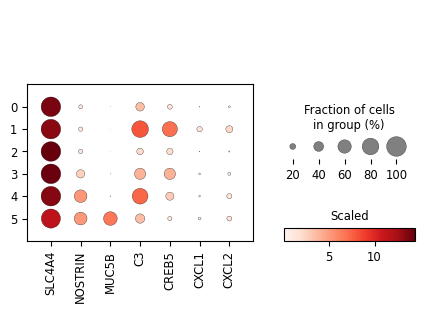

In [276]:
fig, ax = plt.subplots(figsize=[5, 3])
sc.pl.dotplot(ductal_show, 
              var_names = [
                    'SLC4A4',
                    'NOSTRIN', 'MUC5B',
                    'C3', 'CREB5', 
                    'CXCL1', 'CXCL2',], 
              groupby=f"leiden_r{resolution}",
              color_map='Reds', 
              colorbar_title = 'Scaled', 
              ax=ax)

<Axes: title={'center': 'MUC5B'}, xlabel='UMAP1', ylabel='UMAP2'>

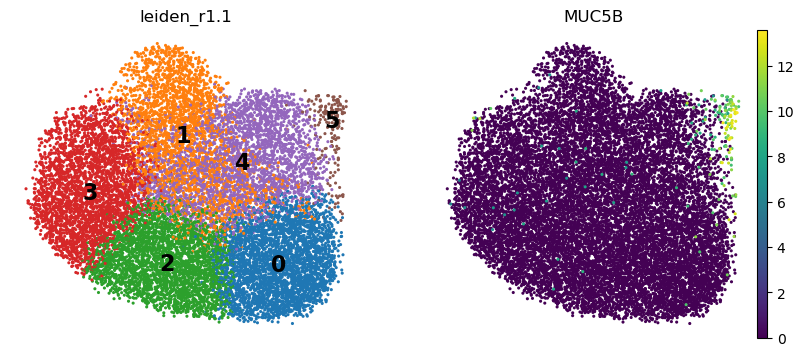

In [22]:
fig, axs = plt.subplots(1,2, figsize = (10,4))
sc.pl.umap(ductal, color = f"leiden_r{resolution}", size=20, show=False, 
           frameon = False, legend_loc = 'on data', legend_fontsize=16, ax=axs[0])
sc.pl.umap(ductal, color = 'MUC5B',size=20, show=False,  frameon = False,  ax=axs[1])

/tmp/ipykernel_4500/1435264987.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_n = ductal.obs.groupby(['leiden_r1.1', 'Sex']).size().unstack().T


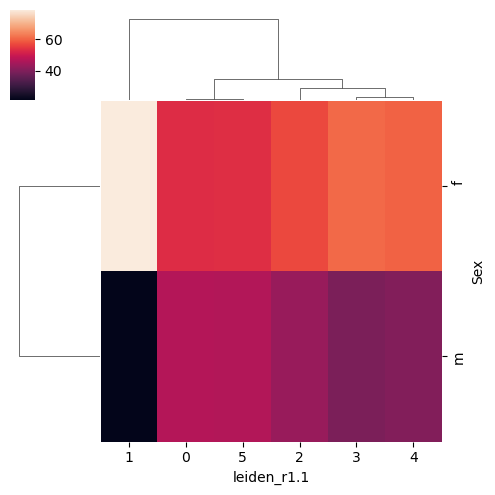

In [115]:
ductal_n = ductal.obs.groupby(['leiden_r1.1', 'Sex']).size().unstack().T
ductal_n = ductal_n * 100 / ductal_n.sum(axis=0)
sns.clustermap(ductal_n, figsize=[5, 5])

In [30]:
metadata.loc[['V2', 'U6']]

,doublet_score,Sex,BMI,T1D,Diabetes Duration,T2D,HbA1c (%),HbA1c,Age,CIT (hours),Cohort,RIN,Nuclei isolation,group
V2,0.012214,f,42.0,no,NaN,no,NaN,NaN,29,NaN,Vienna,6.7,yes,ND - Obese
U6,0.020701,f,25.5,no,NaN,no,6%,42.0,62,NaN,Uppsala,NaN,yes,ND - Lean


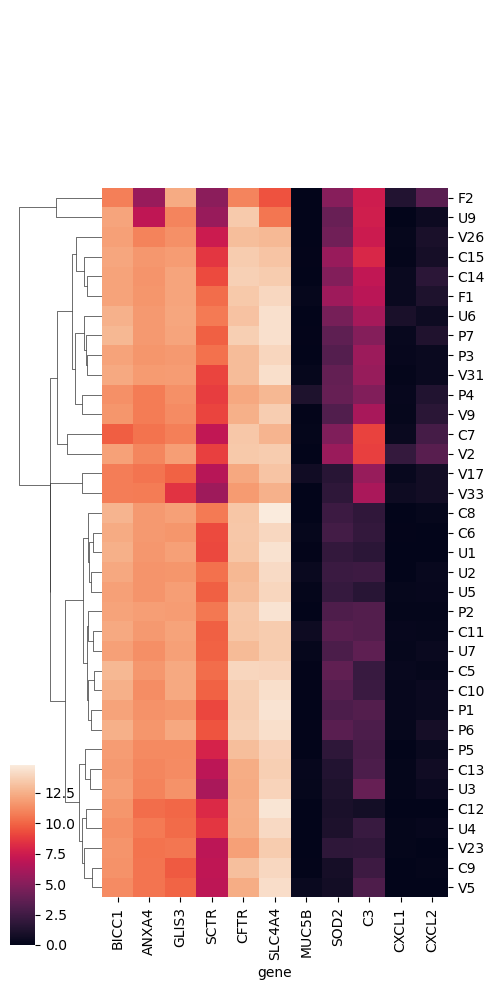

In [55]:
genes = [
    'BICC1', 'ANXA4', 'GLIS3', 'SCTR',
    'CFTR', 'SLC4A4',
    'MUC5B', 
    'SOD2', 'C3', 'CXCL1', 'CXCL2',], 

group = 'sample'
ave_exp = pd.DataFrame([], index=ductal.var_names, columns= ductal.obs[group].cat.categories)
for col in ave_exp.columns:
    ave_exp[col] = np.asarray(ductal[ductal.obs[group] == col].X.mean(axis=0))[0]
    
sns.clustermap(ave_exp.loc[genes].T, col_cluster=False, cbar_pos=(0.02, 0.05, 0.05, 0.18),
               figsize=[5, 10])

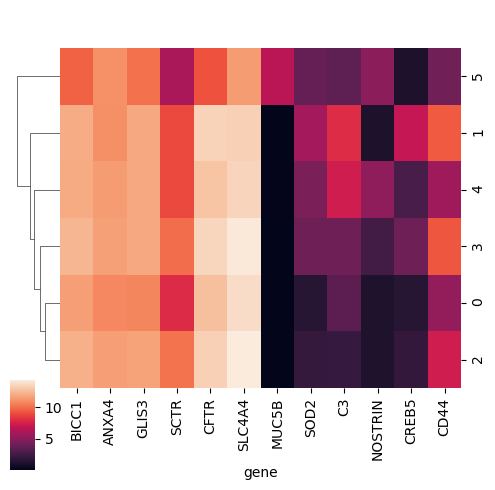

In [56]:
genes = [
    'BICC1', 'ANXA4', 'GLIS3', 'SCTR',
    'CFTR', 'SLC4A4',
    'MUC5B', 
    'SOD2', 'C3', 
    'NOSTRIN', 'CREB5', 'CD44', 
], 

group = 'leiden_r1.1'
ave_exp = pd.DataFrame([], index=ductal.var_names, columns= ductal.obs[group].cat.categories)
for col in ave_exp.columns:
    ave_exp[col] = np.asarray(ductal[ductal.obs[group] == col].X.mean(axis=0))[0]
    
sns.clustermap(ave_exp.loc[genes].T, col_cluster=False, cbar_pos=(0.02, 0.05, 0.05, 0.18),
               figsize=[5, 5], dendrogram_ratio=0.1)

In [21]:
sc.pl.dotplot(ductal_show, 
              var_names = ductal_genes + ['SOD2', 'C3', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', ], 
              groupby = 'new_annotation',
              color_map='RdBu_r',  # Blue to red diverging
              colorbar_title = 'Z score',
              vcenter=0, vmin=-1, vmax=1
              )

ValueError: groupby has to be a valid observation. Given new_annotation, is not in observations: ['sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'leiden_r1.1'] or index name "bc_wells"

## combine cluster 0 and 2

In [8]:
ductal_new = ductal.copy()

ductal_new.obs['new_annotation'] = np.nan

ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == '5', 'new_annotation'] = 'MUC5B+_ductal'
ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'].isin(['0', '2']), 'new_annotation'] = 'Ductal'

for i in ['1', '3', '4']:
    ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == i, 'new_annotation'] = i

/tmp/ipykernel_111357/472342525.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MUC5B+_ductal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == '5', 'new_annotation'] = 'MUC5B+_ductal'


In [9]:
sc.tl.rank_genes_groups(ductal_new, groupby='new_annotation')

In [16]:
cluster = '1'
sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MYH9,48.382275,3.684909,0.000000e+00,0.000000e+00
1,CREB5,47.067982,4.698976,0.000000e+00,0.000000e+00
2,C3,43.415581,3.983639,0.000000e+00,0.000000e+00
3,TPM1,39.205723,2.939984,5.448619e-294,5.252469e-290
4,MYO1B,37.347958,3.329572,7.038725e-264,5.428264e-260
5,SAMD4A,37.146614,3.587155,1.195683e-260,7.684254e-257
6,SLCO3A1,33.534969,3.350061,3.797787e-216,1.830534e-212
7,RELB,33.041050,3.741569,2.088243e-206,7.320242e-203
8,SPTBN1,32.931206,2.440911,6.830885e-215,2.926655e-211
9,CD44,32.299274,2.575949,1.285030e-207,4.955077e-204


In [23]:
gsea_analysis(
    sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(100)['names'].tolist(), 
    '../figures/', 
    f'Pathways_enriched_in_cluster{cluster}_ductal_leiden_r1.1',
    f'Pathways enriched in cluster{cluster}')

In [24]:
cluster = '3'
sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(20)
# ATP1B1, ATP1A1, CTTNBP2 are related with energy

,names,scores,logfoldchanges,pvals,pvals_adj
0,ATP1B1,54.467960,3.314219,0.0,0.0
1,VAV3,54.168987,3.713991,0.0,0.0
2,LHFPL3-AS2,51.890415,4.136904,0.0,0.0
3,PBX3,51.455425,2.898299,0.0,0.0
4,CLASP1,49.944000,2.701913,0.0,0.0
5,CTTNBP2,49.840374,3.409993,0.0,0.0
6,DDX17,49.227173,2.420211,0.0,0.0
7,CDK14,48.420773,1.930173,0.0,0.0
8,DCDC2,48.273407,2.046085,0.0,0.0
9,KCNJ16,48.161316,2.793355,0.0,0.0


In [26]:
gsea_analysis(
    sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(100)['names'].tolist(), 
    '../figures/', 
    f'Pathways_enriched_in_cluster{cluster}_ductal_leiden_r1.1',
    f'Pathways enriched in cluster{cluster}')

In [27]:
cluster = '4'
sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(20)
# ATP1B1, ATP1A1, CTTNBP2 are related with energy

,names,scores,logfoldchanges,pvals,pvals_adj
0,NOSTRIN,39.864433,4.238675,8.789660e-289,1.694647e-284
1,C6,37.162796,3.164236,2.665868e-266,2.055918e-262
2,DPYD,34.936871,3.403961,3.292018e-234,2.115670e-230
3,C3,33.609859,3.206662,6.953747e-222,3.351706e-218
4,LINC01320,31.462532,3.291634,6.533202e-193,2.799114e-189
5,TMC5,29.680561,3.284521,2.455559e-173,8.607852e-170
6,C4orf19,28.330622,2.092552,5.152393e-165,1.655636e-161
7,DOCK4,28.060631,2.759708,8.840675e-159,2.622280e-155
8,MTUS1,26.629036,2.159849,3.101865e-146,7.475495e-143
9,LINC02343,26.492418,2.709302,5.204440e-143,1.180489e-139


In [28]:
gsea_analysis(
    sc.get.rank_genes_groups_df(ductal_new, group=cluster).head(100)['names'].tolist(), 
    '../figures/', 
    f'Pathways_enriched_in_cluster{cluster}_ductal_leiden_r1.1',
    f'Pathways enriched in cluster{cluster}')

## combine cluster 0, 2, 3

In [87]:
ductal_new.obs['new_annotation2'] = np.nan

ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == '5', 'new_annotation2'] = 'MUC5B+_ductal'
ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'].isin(['0', '2', '3']), 'new_annotation2'] = 'Ductal'

for i in ['1', '4']:
    ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == i, 'new_annotation2'] = i

/tmp/ipykernel_4500/3507760790.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MUC5B+_ductal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ductal_new.obs.loc[ductal_new.obs['leiden_r1.1'] == '5', 'new_annotation2'] = 'MUC5B+_ductal'


In [91]:
sc.tl.rank_genes_groups(ductal_new, groupby='new_annotation2')

In [92]:
sc.get.rank_genes_groups_df(ductal_new, group='1').head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MYH9,48.382275,3.684909,0.000000e+00,0.000000e+00
1,CREB5,47.067982,4.698976,0.000000e+00,0.000000e+00
2,C3,43.415581,3.983639,0.000000e+00,0.000000e+00
3,TPM1,39.205723,2.939984,5.448619e-294,5.252469e-290
4,MYO1B,37.347958,3.329572,7.038725e-264,5.428264e-260
5,SAMD4A,37.146614,3.587155,1.195683e-260,7.684254e-257
6,SLCO3A1,33.534969,3.350061,3.797787e-216,1.830534e-212
7,RELB,33.041050,3.741569,2.088243e-206,7.320242e-203
8,SPTBN1,32.931206,2.440911,6.830885e-215,2.926655e-211
9,CD44,32.299274,2.575949,1.285030e-207,4.955077e-204


In [93]:
sc.get.rank_genes_groups_df(ductal_new, group='4').head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NOSTRIN,39.864433,4.238675,8.789660e-289,1.694647e-284
1,C6,37.162796,3.164236,2.665868e-266,2.055918e-262
2,DPYD,34.936871,3.403961,3.292018e-234,2.115670e-230
3,C3,33.609859,3.206662,6.953747e-222,3.351706e-218
4,LINC01320,31.462532,3.291634,6.533202e-193,2.799114e-189
5,TMC5,29.680561,3.284521,2.455559e-173,8.607852e-170
6,C4orf19,28.330622,2.092552,5.152393e-165,1.655636e-161
7,DOCK4,28.060631,2.759708,8.840675e-159,2.622280e-155
8,MTUS1,26.629036,2.159849,3.101865e-146,7.475495e-143
9,LINC02343,26.492418,2.709302,5.204440e-143,1.180489e-139


## compare cluster 1 & 4

In [96]:
ductal_14 = ductal[ductal.obs['leiden_r1.1'].isin(['1', '4'])].copy()

In [97]:
sc.tl.rank_genes_groups(ductal_14, groupby='leiden_r1.1')

In [98]:
sc.get.rank_genes_groups_df(ductal_14, group='1').head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MYH9,38.065205,3.966226,6.865100e-282,8.823942e-278
1,CREB5,35.767567,4.388174,2.079437e-252,1.603662e-248
2,CD44,33.868713,3.778960,1.628140e-228,1.046351e-224
3,TPM1,30.840197,3.182610,8.878208e-193,4.279296e-189
4,SGCZ,29.222218,4.158419,7.542360e-173,2.423612e-169
5,SLCO3A1,27.162365,3.349118,1.043663e-152,2.874546e-149
6,SAMD4A,26.964104,3.337443,7.746620e-151,1.991398e-147
7,DCDC2,26.935539,2.503620,6.995563e-150,1.685931e-146
8,FLNA,26.701216,3.338184,1.719961e-146,3.684539e-143
9,KAZN,26.699602,3.416328,2.081498e-147,4.721327e-144


In [99]:
sc.get.rank_genes_groups_df(ductal_14, group='4').head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NOSTRIN,39.593449,4.947917,3.717982e-298,7.168269e-294
1,KCNJ15,39.285801,4.616143,6.791945e-299,2.618974e-294
2,C6,36.317814,4.158529,2.218728e-259,2.138854e-255
3,LINC02343,32.239056,4.058284,3.849056e-209,2.120280e-205
4,LINC01320,30.551949,3.804748,1.005136e-188,4.306449e-185
5,LINC02532,30.048258,2.726081,4.238697e-180,1.634442e-176
6,RALYL,29.645870,3.919534,1.095879e-179,3.841553e-176
7,DPYD,28.118237,3.411814,5.205144e-163,1.543926e-159
8,PCDH9,25.966236,3.464538,1.703680e-140,3.128281e-137
9,LINC02889,25.707731,3.265061,5.304680e-138,9.297657e-135


## pathway analysis

In [190]:
Inflam1 = sc.get.rank_genes_groups_df(ductal_14, group='1')
Inflam2 = sc.get.rank_genes_groups_df(ductal_14, group='4')

In [208]:
import gseapy as gp
from gseapy.plot import barplot
import os

def gsea_analysis(genes, path, fn, title):
    res = gp.enrichr(gene_list=genes,
                     gene_sets=['GO_Biological_Process_2023'],
                     organism='Human',
                     cutoff=0.05)
    if fn is not False:
        res.res2d.to_csv(os.path.join(path, fn + '.tsv'), sep='\t')

    barplot(res.res2d, column='Adjusted P-value', Group='Gene_Set',
            size=10, top_term=10, 
            title=title, ofname=os.path.join(path, fn + '.png'),
            cutoff=1.0)
    return res

In [209]:
path = '../tables/cst_characterization/'

for rank_df, cst, ref in zip([Inflam1, Inflam2], 
                        ['inflam_ductal_1', 'inflam_ductal_2'], 
                        ['inflam_ductal_2', 'inflam_ductal_1']):
    g_list = rank_df.head(300)['names'].tolist()
    fn = f'pathways_enriched_in_{cst}_vs_{ref}'
    title = f'pathways_enriched_in_{cst}_vs_{ref}'
    res = gsea_analysis(g_list, path, fn, title)

## save the annotation to adata

In [214]:
# load adata's raw data first
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

ductal_new.obs['cst1'] = pd.Series([None] * ductal_new.n_obs, dtype='object')

ductal_new.obs.loc[ductal_new.obs['new_annotation2'] == 'MUC5B+_ductal', 'cst1'] = 'MUC5B+_ductal'
ductal_new.obs.loc[ductal_new.obs['new_annotation2'] == 'Ductal', 'cst1'] = 'Basel_ductal'
ductal_new.obs.loc[ductal_new.obs['new_annotation2'].isin(['1', '4']), 'cst1' ] = 'Inflam_ductal'

ductal_new.obs['cst2'] = pd.Series([None] * ductal_new.n_obs, dtype='object')

ductal_new.obs.loc[ductal_new.obs['new_annotation2'] == 'MUC5B+_ductal', 'cst2' ] = 'MUC5B+_ductal'
ductal_new.obs.loc[ductal_new.obs['new_annotation2'] == 'Ductal', 'cst2' ] = 'Basel_ductal'
ductal_new.obs.loc[ductal_new.obs['new_annotation2'].isin(['1']), 'cst2' ] = 'Inflam_ductal_1'
ductal_new.obs.loc[ductal_new.obs['new_annotation2'].isin(['4']), 'cst2' ] = 'Inflam_ductal_2'

adata.obs.loc[ductal_new.obs.index, 'cst1'] = ductal_new.obs['cst1']
adata.obs.loc[ductal_new.obs.index, 'cst2'] = ductal_new.obs['cst2']

adata.write_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

In [226]:
adata.obs['cst1'].value_counts()

cst1
Basel_ductal     10069
Inflam_ductal     5715
MUC5B+_ductal      172
Name: count, dtype: int64

In [227]:
adata.obs['cst2'].value_counts()

cst2
Basel_ductal       10069
Inflam_ductal_2     2962
Inflam_ductal_1     2753
MUC5B+_ductal        172
Name: count, dtype: int64

## make plots for ductal subtypes

In [213]:
path = '../tables/cst_characterization/'
sc.tl.rank_genes_groups(ductal_new, groupby='cst1')

for cst in ['MUC5B+_ductal', 'Basel_ductal', 'Inflam_ductal']:
    rank_df = sc.get.rank_genes_groups_df(ductal_new, group=cst)
    
    g_list = rank_df.head(300)['names'].tolist()
    fn = f'pathways_enriched_in_{cst}_vs_rest'
    title = f'pathways_enriched_in_{cst}_vs_rest'
    res = gsea_analysis(g_list, path, fn, title)

In [228]:
path = '../tables/cst_characterization/'
sc.tl.rank_genes_groups(ductal_new, groupby='cst2')

for cst in ['Inflam_ductal_1', 'Inflam_ductal_2']:
    rank_df = sc.get.rank_genes_groups_df(ductal_new, group=cst)
    
    g_list = rank_df.head(300)['names'].tolist()
    fn = f'pathways_enriched_in_{cst}_vs_rest'
    title = f'pathways_enriched_in_{cst}_vs_rest'
    res = gsea_analysis(g_list, path, fn, title)

/tmp/ipykernel_4500/1050031342.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_n = ductal_new.obs.groupby(['cst2', 'Sex']).size().unstack().T


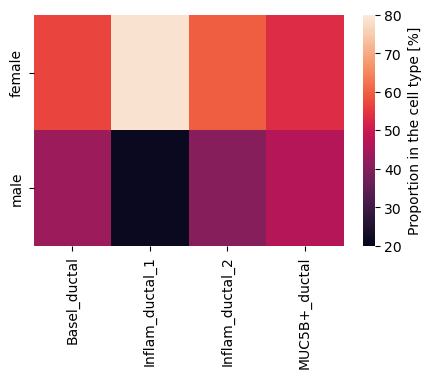

In [254]:
ductal_n = ductal_new.obs.groupby(['cst2', 'Sex']).size().unstack().T
ductal_n = ductal_n * 100 / ductal_n.sum(axis=0)

fig, ax = plt.subplots(figsize=[5, 3], )
sns.heatmap(ductal_n, ax=ax, 
            cbar_kws={'label': 'Proportion in the cell type [%]'},
            vmin=20, vmax=80)

ax.set_xlabel(None)
ax.set_ylabel(None)

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['female', 'male'])

fig.savefig('../figures/cst_characterization/sex_ductal_cells.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_4500/942727847.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_n = ductal_new.obs.groupby(['cst1', 'Sex']).size().unstack().T


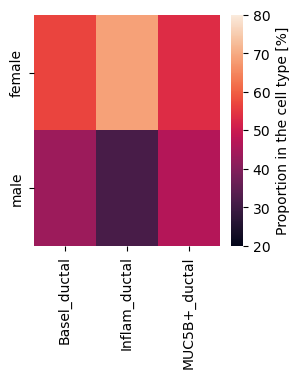

In [256]:
ductal_n = ductal_new.obs.groupby(['cst1', 'Sex']).size().unstack().T
ductal_n = ductal_n * 100 / ductal_n.sum(axis=0)

fig, ax = plt.subplots(figsize=[3, 3], )
sns.heatmap(ductal_n, ax=ax, 
            cbar_kws={'label': 'Proportion in the cell type [%]'},
            vmin=20, vmax=80)

ax.set_xlabel(None)
ax.set_ylabel(None)

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['female', 'male'])

fig.savefig('../figures/cst_characterization/sex_ductal_cells_2.png', dpi=300, bbox_inches='tight')

In [6]:
ductal_new = adata[adata.obs['cell_type'] == 'Ductal'].copy()

In [7]:
ductal_genes = [
    'BICC1', 'ANXA4', 'GLIS3', 'SCTR',
    'MUC5B', 'TFF3', 
    'CFTR', 'SLC4A4',
    'SOD2', 'JUN', 
    'NOSTRIN', 'CREB5', 'CD44', 
    'MYH9', 'KCNJ15',
    "CRP", "SERPINA3", "CIITA", "VCAM1", "CXCL8", "STAT3", "PLA2G4C", "CXCL1", 
    'C3', "FOS", "HSPG2", "CXCL2", "HDAC9", "THBS1", "CX3CL1", "NFKB1", "RELB", 
    "NFKB2", "ELF3", "IRAK2", "CCL2", 'ATP1B1', 'ATP1A1', 'CTTNBP2']

ductal_show = ductal_new[:, ductal_genes].copy()
sc.pp.scale(ductal_show, zero_center=False)

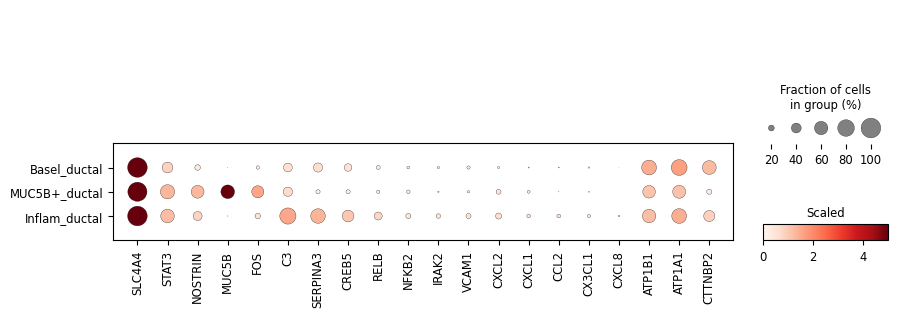

In [9]:
fig, ax = plt.subplots(figsize=[10, 3])
sc.pl.dotplot(ductal_show, 
              var_names = [
                  'SLC4A4', "STAT3", 'NOSTRIN', 
                  'MUC5B', "FOS",
                  "C3", "SERPINA3", 'CREB5', 
#                   "ELF3", "HSPG2", 
#                   "CIITA", "HDAC9", "THBS1",  "PLA2G4C",
                  "RELB", "NFKB2", "IRAK2", "VCAM1", 
                  "CXCL2", "CXCL1", "CCL2", "CX3CL1", "CXCL8", 
                  'ATP1B1', 'ATP1A1', 'CTTNBP2'
              ], 
              groupby=f"cst1",
              categories_order=['Basel_ductal', 'MUC5B+_ductal', 'Inflam_ductal'],
              color_map='Reds', 
              colorbar_title ='Scaled', vmax=5,
              use_raw=False,
              ax=ax)
fig.savefig('../figures/cst_characterization/dotplot_cst1.png', 
            dpi=300, bbox_inches='tight')

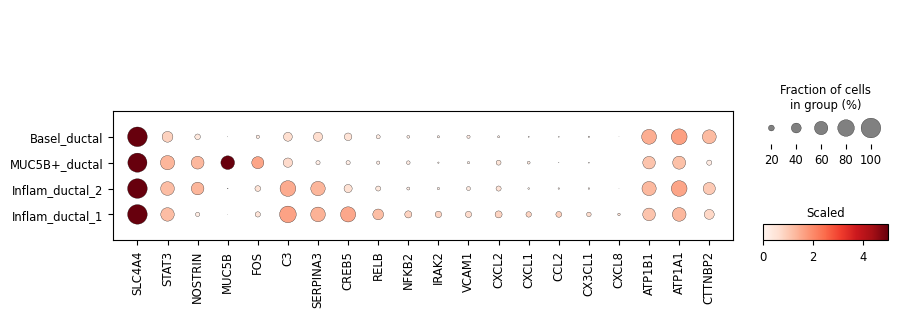

In [10]:
fig, ax = plt.subplots(figsize=[10, 3])
sc.pl.dotplot(ductal_show, 
              var_names = [
                  'SLC4A4', "STAT3", 'NOSTRIN', 
                  'MUC5B', "FOS",
                  "C3", "SERPINA3", 'CREB5', 
#                   "ELF3", "HSPG2", 
#                   "CIITA", "HDAC9", "THBS1",  "PLA2G4C",
                  "RELB", "NFKB2", "IRAK2", "VCAM1", 
                  "CXCL2", "CXCL1", "CCL2", "CX3CL1", "CXCL8",  'ATP1B1', 'ATP1A1', 'CTTNBP2'
              ], 
              groupby=f"cst2",
              categories_order=['Basel_ductal', 'MUC5B+_ductal', 
                                'Inflam_ductal_2', 'Inflam_ductal_1'],
              color_map='Reds', 
              colorbar_title = 'Scaled', vmax=5,
              use_raw=False,
              ax=ax)
fig.savefig('../figures/cst_characterization/dotplot_cst2.png', 
            dpi=300, bbox_inches='tight')

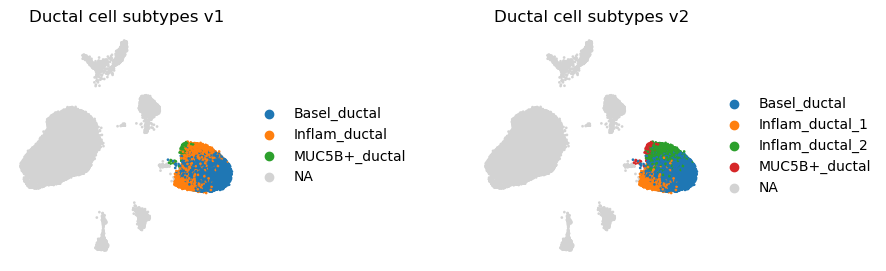

In [320]:
fig, axs = plt.subplots(1, 2, figsize=[9, 3])
plt.subplots_adjust(wspace=1)
sc.pl.umap(adata, color='cst1', ax=axs[0], size=15, show=False,  frameon = False)
axs[0].set_title('Ductal cell subtypes v1')
sc.pl.umap(adata, color='cst2', ax=axs[1], size=15, show=False,  frameon = False)
axs[1].set_title('Ductal cell subtypes v2')
fig.savefig('../figures/cst_characterization/adata_UMAP_1.png', 
            dpi=300, bbox_inches='tight')

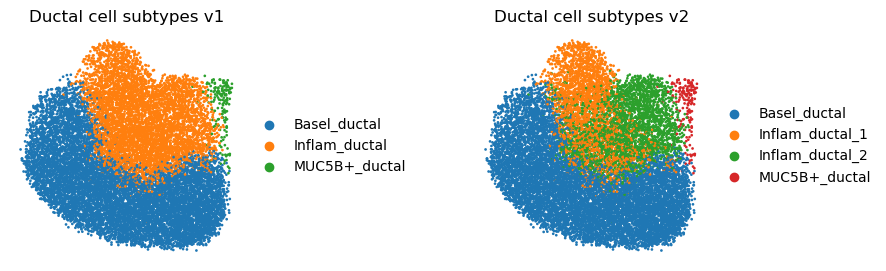

In [322]:
fig, axs = plt.subplots(1, 2, figsize=[9, 3])
plt.subplots_adjust(wspace=1)
sc.pl.umap(ductal_new, color='cst1', ax=axs[0], size=15, show=False,  frameon = False)
axs[0].set_title('Ductal cell subtypes v1')
sc.pl.umap(ductal_new, color='cst2', ax=axs[1], size=15, show=False,  frameon = False)
axs[1].set_title('Ductal cell subtypes v2')
fig.savefig('../figures/cst_characterization/adata_UMAP_2.png', 
            dpi=300, bbox_inches='tight')

## ductal quality control

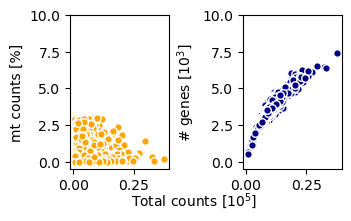

In [20]:
# adata_raw = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')
adata_ductal_raw = adata_raw[adata_raw.obs['cell_type'] == 'Ductal'].copy()

adata_ductal_raw.var['mt'] = adata_ductal_raw.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_ductal_raw, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

## plotting
fig, axs = plt.subplots(1, 2, figsize=(3.5, 2), sharex=True)
plt.subplots_adjust(wspace=0.75)
axs[0].scatter(x=adata_ductal_raw.obs['total_counts']/(10**5), 
               y=adata_ductal_raw.obs['pct_counts_mt'], 
               c='orange', edgecolor='white', s=30)

axs[1].scatter(x=adata_ductal_raw.obs['total_counts']/(10**5), 
               y=adata_ductal_raw.obs['n_genes_by_counts']/(10**3), 
               c='navy', edgecolor='white', s=30)

axs[0].set_ylabel('mt counts [%]')
axs[1].set_ylabel('# genes [$10^3$]')

axs[0].set_ylim(-0.5, 10)
axs[1].set_ylim(-0.5, 10)
axs[0].set_yticks([0, 2.5, 5, 7.5, 10])
axs[1].set_yticks([0, 2.5, 5, 7.5, 10])

fig.text(0.48, -0.05, 'Total counts [$10^5$]', va='center', ha='center')

save_path = '../figures/cst_characterization/'
fig.savefig(save_path + 'ductal_QC.png', bbox_inches='tight', dpi=300)

## ductal abundance

/tmp/ipykernel_22666/3993992272.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'group']].groupby(['cst1', 'group']).size().unstack()


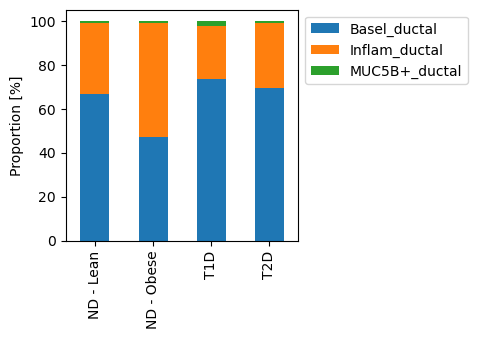

In [56]:
ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'group']].groupby(['cst1', 'group']).size().unstack()
ductal_abundance1 = ductal_abundance1 * 100 / ductal_abundance1.sum(axis=0)

fig, ax = plt.subplots(figsize=[3, 3])
ductal_abundance1.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_group_1.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/3452665601.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'group']].groupby(['cst2', 'group']).size().unstack()


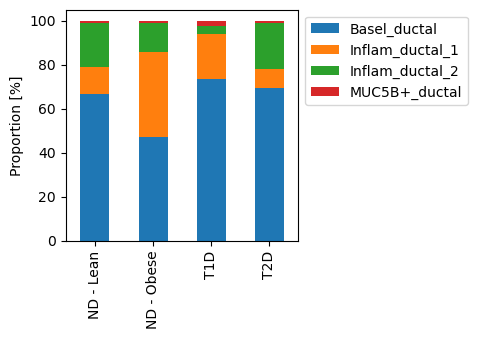

In [57]:
ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'group']].groupby(['cst2', 'group']).size().unstack()
ductal_abundance2 = ductal_abundance2 * 100 / ductal_abundance2.sum(axis=0)

fig, ax = plt.subplots(figsize=[3, 3])
ductal_abundance2.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_group_2.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/482287787.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'Sex']].groupby(['cst1', 'Sex']).size().unstack()


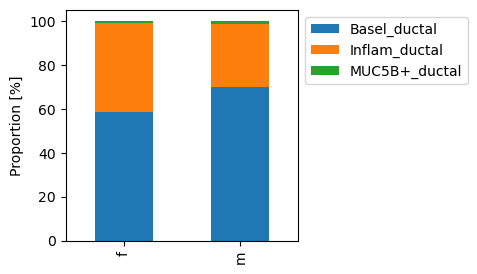

In [59]:
ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'Sex']].groupby(['cst1', 'Sex']).size().unstack()
ductal_abundance1 = ductal_abundance1 * 100 / ductal_abundance1.sum(axis=0)

fig, ax = plt.subplots(figsize=[3, 3])
ductal_abundance1.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_sex_1.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/2037627462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'Sex']].groupby(['cst2', 'Sex']).size().unstack()


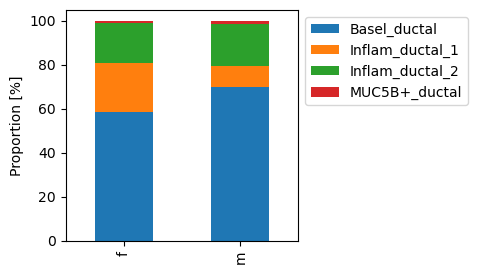

In [60]:
ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'Sex']].groupby(['cst2', 'Sex']).size().unstack()
ductal_abundance2 = ductal_abundance2 * 100 / ductal_abundance2.sum(axis=0)

fig, ax = plt.subplots(figsize=[3, 3])
ductal_abundance2.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_sex_2.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/523715625.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_ductal_raw.obs.groupby(['cst1', 'sample',]).size().unstack().T


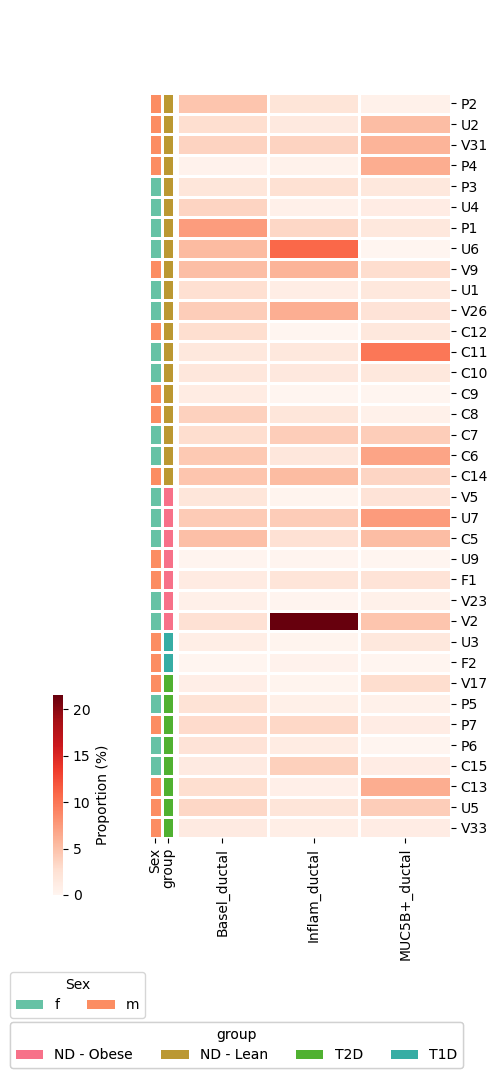

In [90]:
df = adata_ductal_raw.obs.groupby(['cst1', 'sample',]).size().unstack().T
df = (df / df.sum(axis=0) * 100)

df = df.loc[metadata['group'].sort_values().index]

color_elements1 = sns.color_palette('Set2')
color_elements2 = sns.color_palette('husl')

color_dict = {}
handles = {}
color_cols = {}

for col, color_elements in zip(['Sex','group'], [color_elements1, color_elements2]):
    color_col = dict(zip(metadata[col].unique(), color_elements[:len(metadata[col].unique())]))
    color_dict[col] = metadata[col].map(color_col)
    handles[col] = [Patch(facecolor=color, label=name) 
                    for name, color in color_col.items()]
    color_cols[col] = color_col

color_df = pd.DataFrame(color_dict, index=metadata.index)

g = sns.clustermap(
    df,
    cmap='Reds',
    row_cluster=False,
    col_cluster=False,
    row_colors=color_df,
    linewidths=0.9,
    cbar_pos=[0.1, 0.1, 0.02, 0.2],
    cbar_kws={'label':'Proportion (%)'},
    tree_kws={'linewidths': 1},
    dendrogram_ratio=(0.3, 0.1),
    figsize=[5, 10],
        )

g.ax_heatmap.set_xlabel(None)
g.ax_heatmap.set_ylabel(None)

fig = plt.gcf()

for i, col in enumerate(['Sex', 'group']):


    legend = plt.legend(handles[col], 
                        [patch.get_label() for patch in handles[col]],
                        title=col,
                        bbox_to_anchor=(0, 0 - 0.05 * i), 
                        bbox_transform=plt.gcf().transFigure, 
                        loc='center left', ncols = min(4, len(handles[col])))
    fig.add_artist(legend)
    
fig.savefig('../figures/cst_characterization/ductal_cst_abundance_heatmap_sample_1.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/1817126614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_ductal_raw.obs.groupby(['cst2', 'sample',]).size().unstack().T


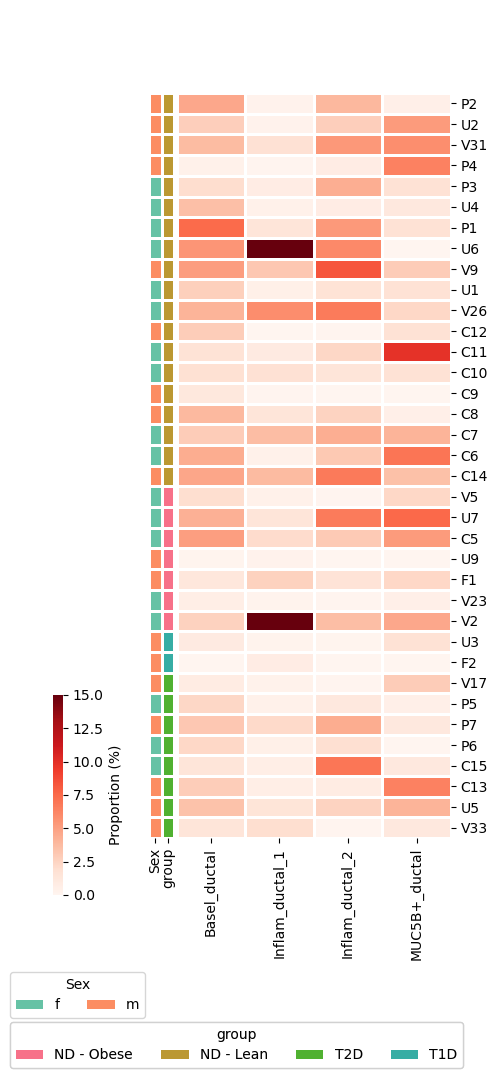

In [91]:
df = adata_ductal_raw.obs.groupby(['cst2', 'sample',]).size().unstack().T
df = (df / df.sum(axis=0) * 100)

df = df.loc[metadata['group'].sort_values().index]

color_elements1 = sns.color_palette('Set2')
color_elements2 = sns.color_palette('husl')

color_dict = {}
handles = {}
color_cols = {}

for col, color_elements in zip(['Sex','group'], [color_elements1, color_elements2]):
    color_col = dict(zip(metadata[col].unique(), color_elements[:len(metadata[col].unique())]))
    color_dict[col] = metadata[col].map(color_col)
    handles[col] = [Patch(facecolor=color, label=name) 
                    for name, color in color_col.items()]
    color_cols[col] = color_col

color_df = pd.DataFrame(color_dict, index=metadata.index)

g = sns.clustermap(
    df,
    cmap='Reds',
    row_cluster=False,
    col_cluster=False,
    row_colors=color_df,
    linewidths=0.9,
    cbar_pos=[0.1, 0.1, 0.02, 0.2],
    cbar_kws={'label':'Proportion (%)'},
    tree_kws={'linewidths': 1},
    dendrogram_ratio=(0.3, 0.1),
    figsize=[5, 10],
    vmax=15
        )

g.ax_heatmap.set_xlabel(None)
g.ax_heatmap.set_ylabel(None)

fig = plt.gcf()

for i, col in enumerate(['Sex', 'group']):


    legend = plt.legend(handles[col], 
                        [patch.get_label() for patch in handles[col]],
                        title=col,
                        bbox_to_anchor=(0, 0 - 0.05 * i), 
                        bbox_transform=plt.gcf().transFigure, 
                        loc='center left', ncols = min(4, len(handles[col])))
    fig.add_artist(legend)
    
fig.savefig('../figures/cst_characterization/ductal_cst_abundance_heatmap_sample_2.png', 
            dpi=300, bbox_inches='tight')

In [11]:
color_elements1 = sns.color_palette('Set2')
color_elements2 = sns.color_palette('husl')

/tmp/ipykernel_46328/1704888677.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'sample']].groupby(['cst1', 'sample']).size().unstack()


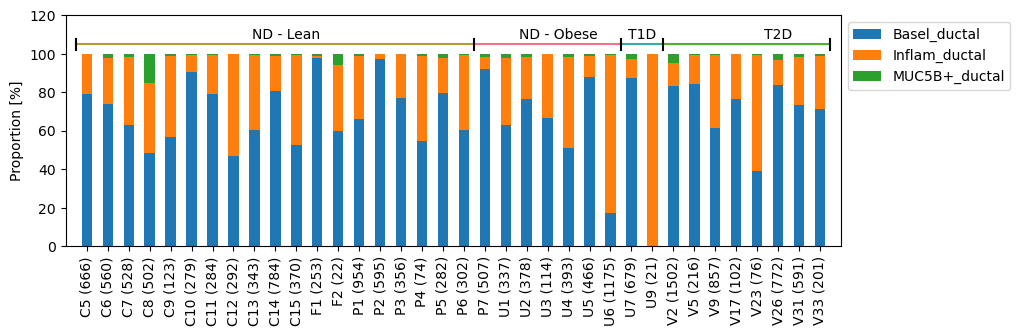

In [16]:
ductal_abundance1 = adata_ductal_raw.obs[['cst1', 'sample']].groupby(['cst1', 'sample']).size().unstack()
ductal_abundance_pct_1 = ductal_abundance1 * 100 / ductal_abundance1.sum(axis=0)

ductal_abundance_pct_1 = ductal_abundance_pct_1[metadata['group'].sort_values().index]

fig, ax = plt.subplots(figsize=[10, 3])
ductal_abundance_pct_1.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

ax.set_ylim(0, 120)
ax.set_xlim(-1, 36)

sample_numbers = [0, 18, 25, 27, 35]

ax.plot([-0.5, 18.5], [105, 105], c=color_elements2[1])
ax.plot([18.5, 25.5], [105, 105], c=color_elements2[0])
ax.plot([25.5, 27.5], [105, 105], c=color_elements2[3])
ax.plot([27.5, 35.5], [105, 105], c=color_elements2[2])

for i in [-0.5, 18.5, 25.5, 27.5, 35.5]:
    ax.plot([i, i], [102, 108], c='k')

ax.text(9.5, 110, 'ND - Lean', va='center', ha='center')
ax.text(22.5, 110, 'ND - Obese', va='center', ha='center')
ax.text(26.5, 110, 'T1D', va='center', ha='center')
ax.text(33, 110, 'T2D', va='center', ha='center')

ductal_summary = ductal_abundance1.sum()
label_list = [f"{idx} ({val})" for idx, val in 
              zip(ductal_summary.index, ductal_summary.values)]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(label_list)

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_sample_1.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_46328/666099227.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'sample']].groupby(['cst2', 'sample']).size().unstack()


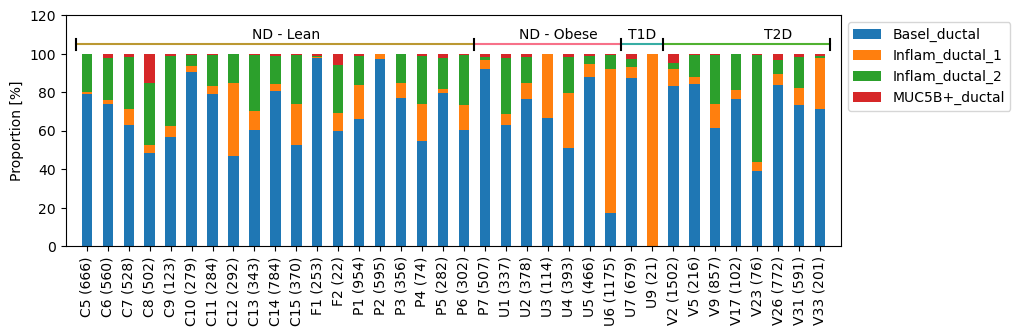

In [17]:
ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'sample']].groupby(['cst2', 'sample']).size().unstack()
ductal_abundance_pct_2 = ductal_abundance2 * 100 / ductal_abundance2.sum(axis=0)

ductal_abundance_pct_2 = ductal_abundance_pct_2[metadata['group'].sort_values().index]

fig, ax = plt.subplots(figsize=[10, 3])
ductal_abundance_pct_2.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

ax.set_ylim(0, 120)
ax.set_xlim(-1, 36)

sample_numbers = [0, 18, 25, 27, 35]

ax.plot([-0.5, 18.5], [105, 105], c=color_elements2[1])
ax.plot([18.5, 25.5], [105, 105], c=color_elements2[0])
ax.plot([25.5, 27.5], [105, 105], c=color_elements2[3])
ax.plot([27.5, 35.5], [105, 105], c=color_elements2[2])

for i in [-0.5, 18.5, 25.5, 27.5, 35.5]:
    ax.plot([i, i], [102, 108], c='k')

ax.text(9.5, 110, 'ND - Lean', va='center', ha='center')
ax.text(22.5, 110, 'ND - Obese', va='center', ha='center')
ax.text(26.5, 110, 'T1D', va='center', ha='center')
ax.text(33, 110, 'T2D', va='center', ha='center')

ductal_summary = ductal_abundance2.sum()
label_list = [f"{idx} ({val})" for idx, val in 
              zip(ductal_summary.index, ductal_summary.values)]

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(label_list)

fig.savefig('../figures/cst_characterization/ductal_cst_abundace_sample_2.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_22666/3424133156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'sample']].groupby(['cst2', 'sample']).size().unstack()


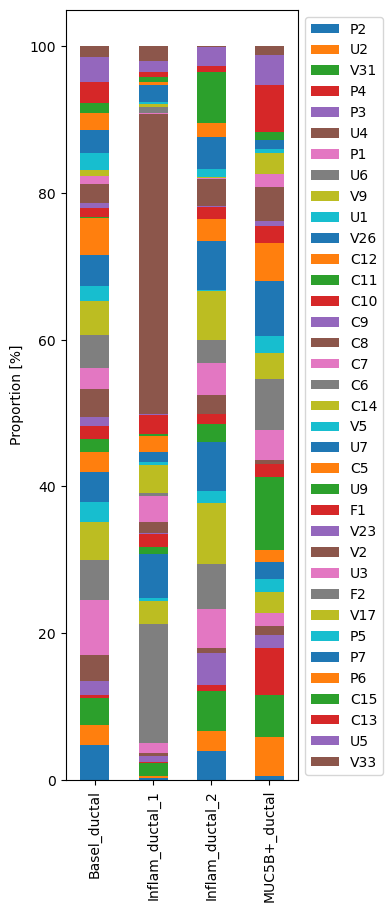

In [127]:
ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'sample']].groupby(['cst2', 'sample']).size().unstack()
ductal_abundance2 = ductal_abundance2.T * 100 / ductal_abundance2.sum(axis=1)

ductal_abundance2 = ductal_abundance2.loc[metadata['group'].sort_values().index]

fig, ax = plt.subplots(figsize=[3, 10])
ductal_abundance2.T.plot.bar(stacked=True, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('Proportion [%]')
ax.legend(bbox_to_anchor=[1, 1])

# ax.set_ylim(0, 120)
# ax.set_xlim(-1, 36)

# sample_numbers = [0, 18, 25, 27, 35]

# ax.plot([-0.5, 18.5], [105, 105], c=color_elements2[1])
# ax.plot([18.5, 25.5], [105, 105], c=color_elements2[0])
# ax.plot([25.5, 27.5], [105, 105], c=color_elements2[3])
# ax.plot([27.5, 35.5], [105, 105], c=color_elements2[2])

# for i in [-0.5, 18.5, 25.5, 27.5, 35.5]:
#     ax.plot([i, i], [102, 108], c='k')

# ax.text(9.5, 110, 'ND - Lean', va='center', ha='center')
# ax.text(22.5, 110, 'ND - Obese', va='center', ha='center')
# ax.text(26.5, 110, 'T1D', va='center', ha='center')
# ax.text(33, 110, 'T2D', va='center', ha='center')

# fig.savefig('../figures/cst_characterization/ductal_cst_abundace_sample_2.png', 
#             dpi=300, bbox_inches='tight')

In [179]:
all_data

,value,label,group
sample,,,
C11,0.098837,C11,ND - Lean
C6,0.069767,C6,ND - Lean
P4,0.063953,P4,ND - Lean
V31,0.058140,V31,ND - Lean
U2,0.052326,U2,ND - Lean
C7,0.040698,C7,ND - Lean
C14,0.034884,C14,ND - Lean
V9,0.029070,V9,ND - Lean
V26,0.023256,V26,ND - Lean


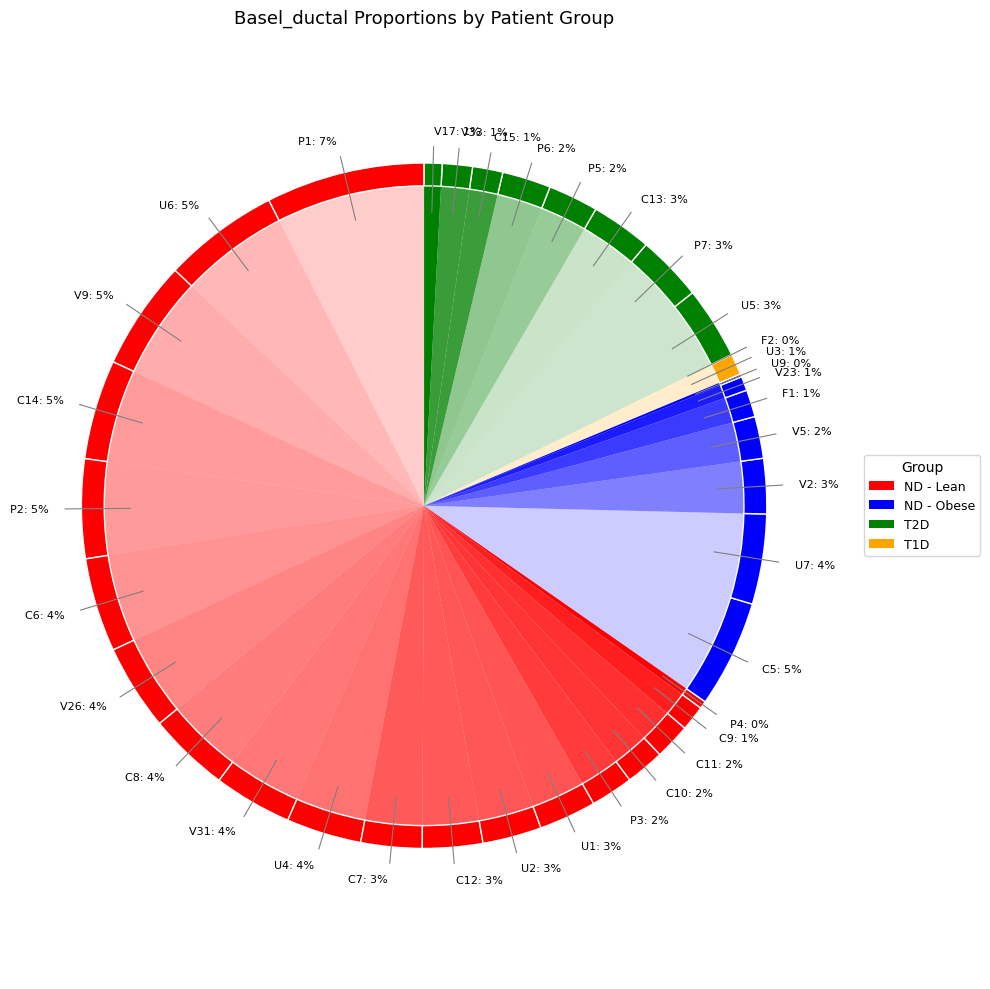

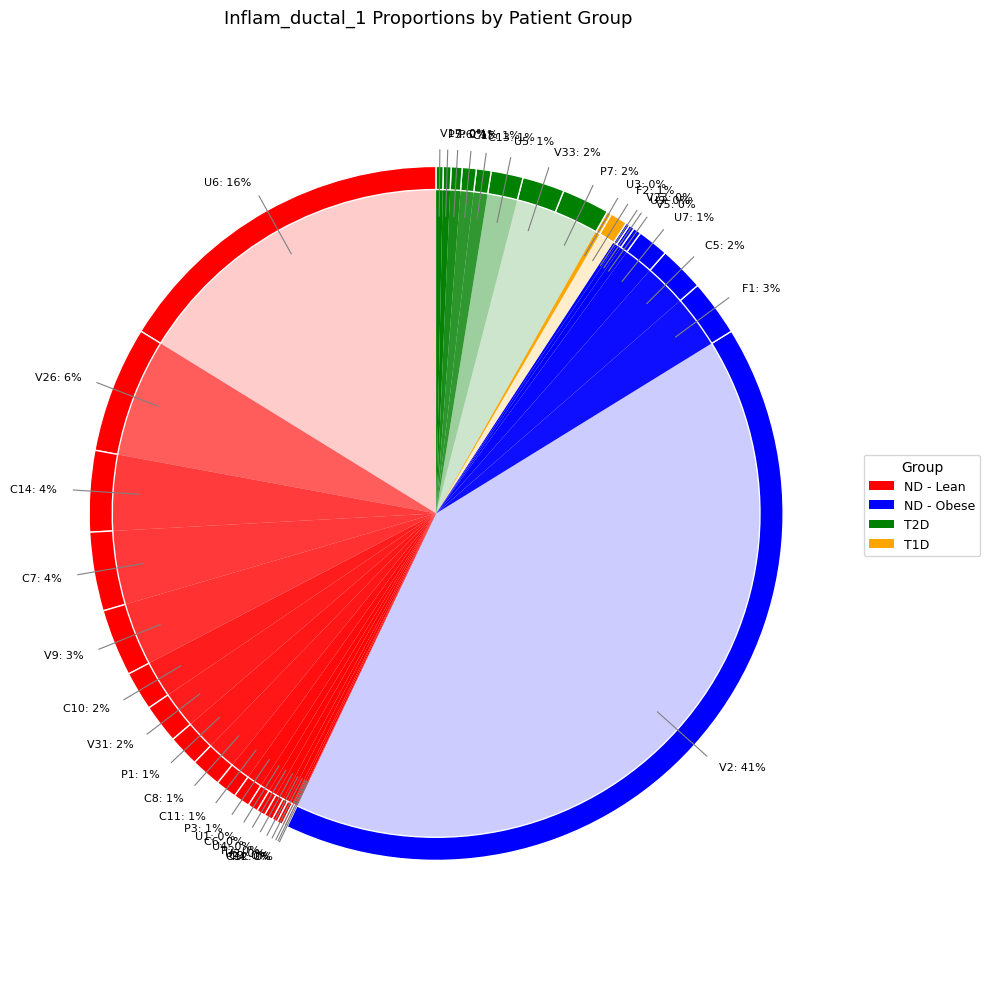

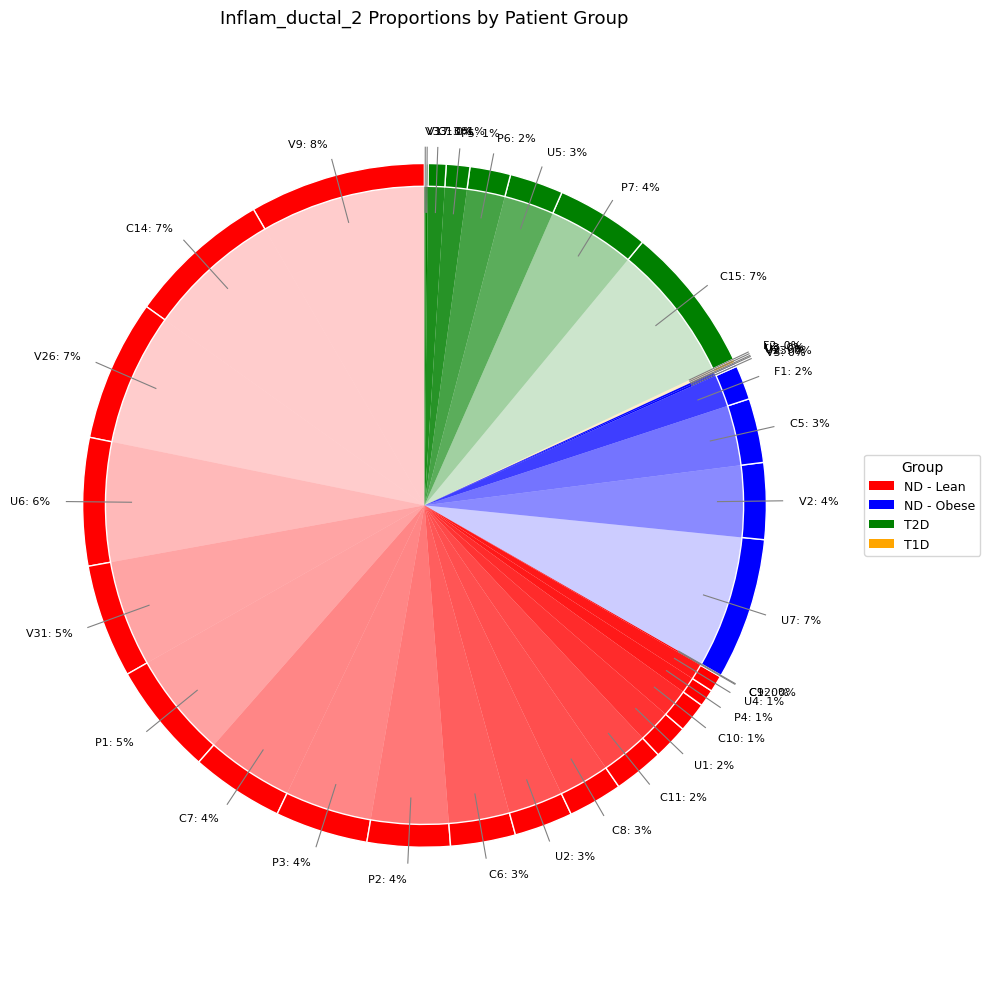

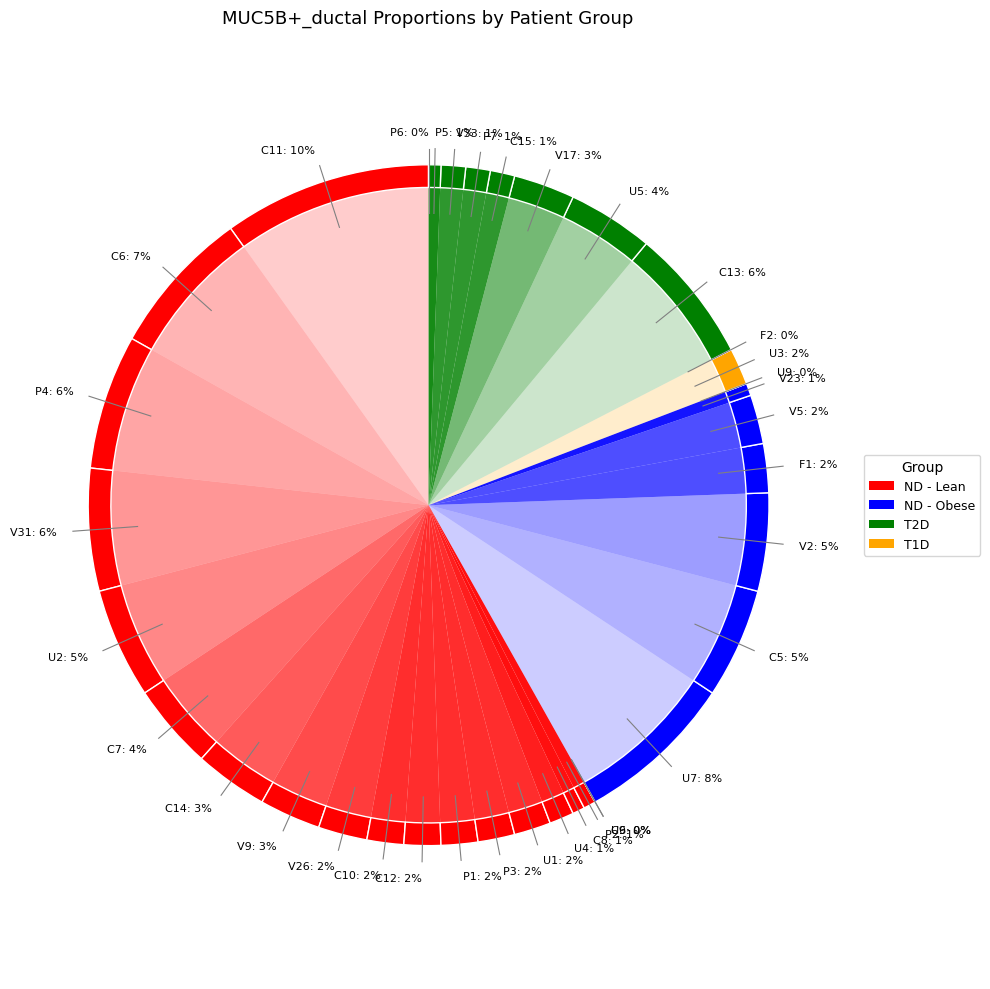

In [177]:
from matplotlib.patches import Wedge, Patch
from matplotlib.colors import to_rgba

# Input data: values (Series), labels (Index), metadata (DataFrame)
# values = ductal_abundance2['Inflam_ductal_1']
# labels = ductal_abundance2.index
# metadata = ...  # must contain 'group' column indexed by labels

ductal_abundance2 = adata_ductal_raw.obs[['cst2', 'sample']].groupby(['cst2', 'sample']).size().unstack()
ductal_abundance2 = ductal_abundance2.T  / ductal_abundance2.sum(axis=1)

for cst in ['Basel_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal']:
    values = ductal_abundance2[cst]
    labels = ductal_abundance2.index

    # Match group metadata
    groups = metadata.loc[labels, 'group']

    # Set up group color mapping
    group_color_map = {
        'ND - Lean': 'red',
        'ND - Obese': 'blue',
        'T2D': 'green',
        'T1D': 'orange'
    }

    # Combine everything into a single dataframe and sort
    all_data = pd.DataFrame({
        'value': values,
        'label': labels,
        'group': groups
    }).sort_values(by=['group', 'value'], ascending=[True, False])

    # Generate slice colors: fixed RGB, alpha varies by proportion
    colors = []
    for group in all_data['group'].unique():
        group_data = all_data[all_data['group'] == group]
        base_rgb = to_rgba(group_color_map[group], alpha=1.0)

        # Invert and normalize for alpha scaling (high value = darker)
        val_norm = (group_data['value'] - group_data['value'].min()) / (
            group_data['value'].max() - group_data['value'].min() + 1e-5
        )
        val_alpha = 1.0 - val_norm
        val_alpha = val_alpha.clip(lower=0.2)  # prevent fully transparent

        for alpha in val_alpha:
            colors.append((*base_rgb[:3], alpha))

    # Format labels
    formatted_labels = [f"{label}: {pct:.0%}" 
                        for label, pct in zip(all_data['label'], all_data['value'])]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    wedges, _ = ax.pie(
        all_data['value'],
        labels=None,
        colors=colors,
        labeldistance=1.15,
        startangle=90
    )

    # Draw outer ring based on group (using wedge angles!)
    for wedge, (_, row) in zip(wedges, all_data.iterrows()):
        ring = Wedge(
            center=(0, 0),
            r=1.05,
            theta1=wedge.theta1,
            theta2=wedge.theta2,
            width=0.07,
            facecolor=group_color_map[row['group']],
            edgecolor='white'
        )
        ax.add_patch(ring)

    # Add labels + connector lines
    for wedge, label in zip(wedges, formatted_labels):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        ax.text(
            1.15 * x, 1.15 * y, label,
            ha='left' if x > 0 else 'right',
            va='center',
            fontsize=8
        )
        ax.plot([0.9 * x, 1.1 * x], [0.9 * y, 1.1 * y], color='gray', lw=0.8)

    # Add legend
    legend_elements = [
        Patch(facecolor=color, label=group)
        for group, color in group_color_map.items()
    ]
    ax.legend(
        handles=legend_elements,
        title="Group",
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        fontsize=9
    )

    # Finalize plot
    ax.set_title(f"{cst} Proportions by Patient Group", fontsize=13)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()
    
    fig.savefig(f'../figures/cst_characterization/pie_{cst}_abundance_by_donor.png', dpi=300, bbox_inches='tight')

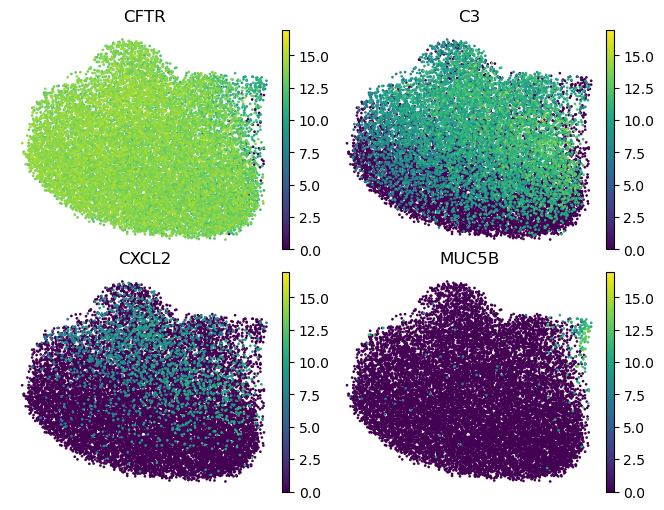

In [19]:
genes = ['CFTR', 'C3','CXCL2', 'MUC5B',]

fig, axs = plt.subplots(2, 2, figsize=[8, 6])
plt.subplots_adjust(wspace=0.1, hspace=0.1)
axs = axs.ravel()

for ax, gene in zip(axs, genes):
    sc.pl.umap(ductal, color=gene, ax=ax, size=15, 
               show=False, frameon = False, vmax=17)
    ax.set_title(gene)

fig.savefig('../figures/cst_characterization/ductal_genes.png', 
            dpi=300, bbox_inches='tight')